In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Iris
data = load_breast_cancer()
X = data.data
y = data.target

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME
explainer = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=30,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)



c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Explication locale (feature, poids):
[(np.str_('worst area'), -0.949007953954716), (np.str_('worst concave points'), -0.7679929582363234), (np.str_('worst perimeter'), -0.595628042561875), (np.str_('worst radius'), -0.5218614873608571), (np.str_('mean concave points'), -0.35665179051583373), (np.str_('area error'), -0.15196923809259189), (np.str_('mean texture'), -0.047207269700332954), (np.str_('radius error'), -0.046701316701316775), (np.str_('worst texture'), -0.04051020408163264), (np.str_('mean area'), 0.0), (np.str_('mean radius'), 0.0), (np.str_('worst smoothness'), 0.0), (np.str_('mean perimeter'), 0.0), (np.str_('symmetry error'), 0.0), (np.str_('mean concavity'), 0.0), (np.str_('worst symmetry'), 0.0), (np.str_('mean smoothness'), 0.0), (np.str_('compactness error'), 0.0), (np.str_('texture error'), 0.0), (np.str_('mean symmetry'), 0.0), (np.str_('mean fractal dimension'), 0.0), (np.str_('worst com

In [3]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=30
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[(np.str_('worst area'), -0.06039356767686831), (np.str_('worst concave points'), -0.0486757340260792), (np.str_('worst perimeter'), -0.04414541825469723), (np.str_('worst radius'), -0.040068803663640004), (np.str_('mean concave points'), -0.03008119596462413), (np.str_('radius error'), -0.027812691411258007), (np.str_('area error'), -0.027598496552066327), (np.str_('worst texture'), -0.026193678777589467), (np.str_('mean texture'), -0.023125644024897696), (np.str_('worst concavity'), -0.021883903245031817), (np.str_('mean concavity'), -0.019726212889910125), (np.str_('mean area'), -0.014157460012592958), (np.str_('mean radius'), -0.009673127242379372), (np.str_('worst smoothness'), -0.009537448566250354), (np.str_('worst symmetry'), -0.00914445679947454), (np.str_('mean perimeter'), -0.005826227351324436), (np.str_('mean smoothness'), -0.005784803824366787), (np.str_('worst compactness'), -0.005203045234437028), (np.str_

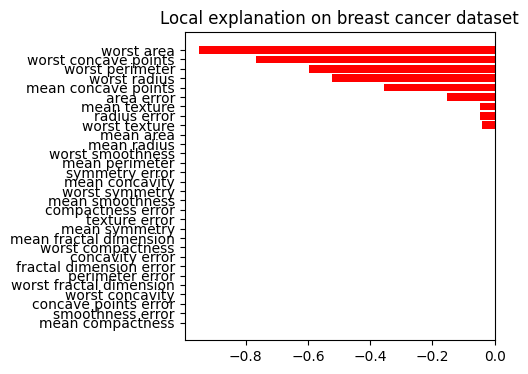

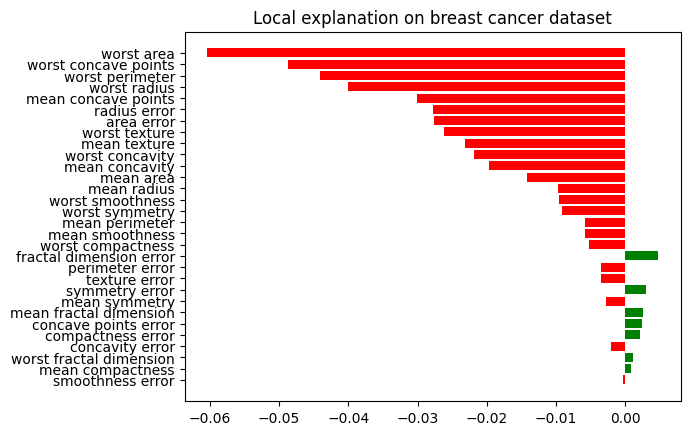

In [4]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
fig.axes[0].set_title("Local explanation on breast cancer dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.axes[0].set_title("Local explanation on breast cancer dataset")
plt.show()